In [ ]:
#CLOSE SESSION. NEED TO RUN BEFORE REFLASHING ARDUINO
ser.close()

In [8]:
#Start Point: Imports and Variables

import subprocess, sys
import serial
import numpy as np
from PIL import Image
import time
import os
import random

IMG_WIDTH, IMG_HEIGHT = 45, 45
IMG_W  = 45
IMG_H  = 45
NUM_CLASSES = 16
CLASS_NAMES = [
    '1.0M_ohm', '1.2M_ohm', '1.5K_ohm', '100_ohm',
    '10K_ohm',  '1K_ohm',   '1_ohm',    '20K_ohm',
    '27K_ohm',  '300_ohm',  '30K_ohm',  '33K_ohm',
    '4.7K_ohm', '43_ohm',   '51_ohm',   '8.2K_ohm',
]

INPUT_SCALE       = 0.003921568859368563
INPUT_ZERO_POINT  = -128
OUTPUT_SCALE      = 0.00390625
OUTPUT_ZERO_POINT = -128

In [9]:
# ── helpers ───────────────────────────────────────────────────────────────────
def preprocess(path):
    img = Image.open(path).resize((IMG_W, IMG_H)).convert("RGB")
    img_float = np.array(img, dtype=np.float32) / 255.0
    return (img_float / INPUT_SCALE + INPUT_ZERO_POINT).astype(np.int8)

def run_inference(ser, img_int8):
    # Wait for Arduino to signal it's ready
    print("  Waiting for Arduino ready signal...")
    while True:
        byte = ser.read(1)
        if byte == b'W':
            break
        elif byte == b'':
            return None, "Timeout waiting for ready signal"

    # Ping
    ser.write(b'P')
    resp = ser.read(1)
    if resp != b'K':
        return None, f"Ping failed: {resp}"

    # Send image
    ser.write(img_int8.flatten().tobytes())

    # Wait for done
    while True:
        byte = ser.read(1)
        if byte == b'D':
            break
        elif byte == b'':
            return None, "Timeout during inference"

    # Read scores
    result_bytes = ser.read(NUM_CLASSES)
    scores_int8  = np.frombuffer(result_bytes, dtype=np.int8)
    scores_float = (scores_int8.astype(np.float32) - OUTPUT_ZERO_POINT) * OUTPUT_SCALE
    return scores_float, None

In [5]:
#Test Connection
# Safely close any existing connection
try:
    ser.close()
except:
    pass

ser = serial.Serial('COM3', 115200, timeout=5)

# Flush startup noise then wait for Arduino to boot and send W
ser.reset_input_buffer()
print("Waiting for Arduino to boot...")
time.sleep(3)

# Connection check
print("Testing connection...")
dummy = np.zeros((IMG_H, IMG_W, 3), dtype=np.int8)
scores, err = run_inference(ser, dummy)
if err:
    print(f"Connection test failed: {err} — try running this cell again")
else:
    print(f"Connection confirmed! (dummy result: {CLASS_NAMES[np.argmax(scores)]})")

Waiting for Arduino to boot...
Testing connection...
  Waiting for Arduino ready signal...
Connection confirmed! (dummy result: 1_ohm)


Found 136 total images, testing 10

Selected images:
   1. 27K_ohm        — val_0001_0005.jpg
   2. 10K_ohm        — val_0004_0006.jpg
   3. 1.5K_ohm       — val_0000_0031.jpg
   4. 43_ohm         — val_0000_0010.jpg
   5. 33K_ohm        — val_0000_0008.jpg
   6. 51_ohm         — val_0000_0025.jpg
   7. 27K_ohm        — val_0000_0006.jpg
   8. 1.2M_ohm       — val_0000_0017.jpg
   9. 1.5K_ohm       — val_0004_0005.jpg
  10. 30K_ohm        — val_0002_0011.jpg
Found 136 total images, testing 10



KeyboardInterrupt: 

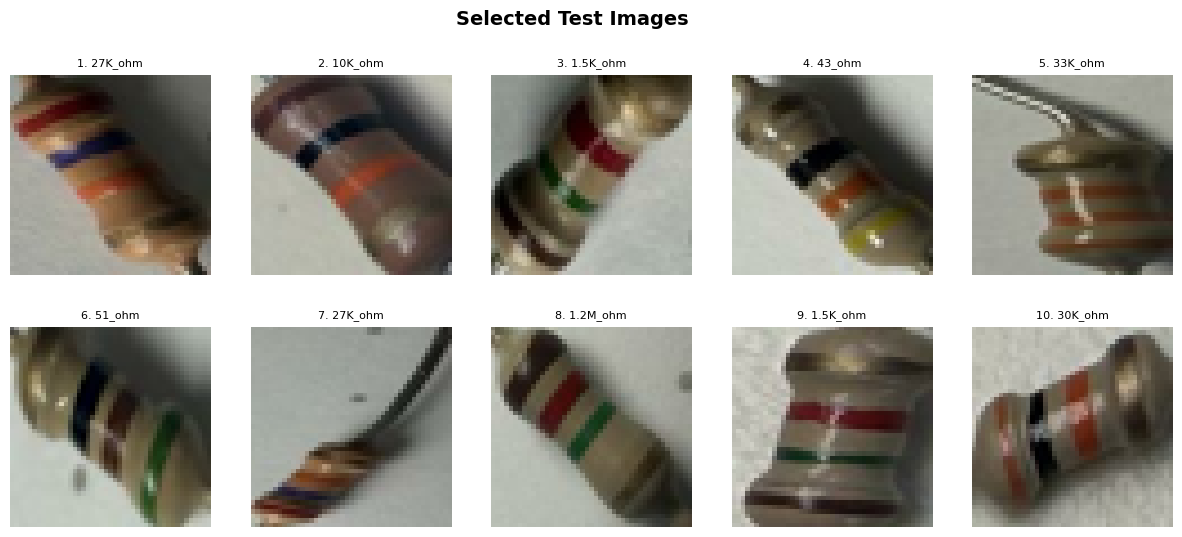

In [31]:
#Grab 10 random resistor photos

SUPPORTED = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


DATA_ROOT = "./demo_data"
NUM_TESTS = 10


all_images = []  # (true_class, filepath)
for class_name in CLASS_NAMES:
    folder = os.path.join(DATA_ROOT, class_name)
    if not os.path.exists(folder):
        # also check train/val/test subfolders
        for split in ["train", "val", "test"]:
            folder = os.path.join(DATA_ROOT, split, class_name)
            if os.path.exists(folder):
                break
    if os.path.exists(folder):
        imgs = [os.path.join(folder, f) for f in os.listdir(folder)
                if os.path.splitext(f)[1].lower() in SUPPORTED]
        for img_path in imgs:
            all_images.append((class_name, img_path))

random.shuffle(all_images)
test_images = all_images[:NUM_TESTS]
print(f"Found {len(all_images)} total images, testing {NUM_TESTS}\n")

print("Selected images:")
for i, (true_class, img_path) in enumerate(test_images):
    print(f"  {i+1:2d}. {true_class:<14} — {os.path.basename(img_path)}")



import matplotlib.pyplot as plt
from PIL import Image

print(f"Found {len(all_images)} total images, testing {NUM_TESTS}\n")

# Display selected images in a grid
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Selected Test Images", fontsize=14, fontweight="bold")

for i, (true_class, img_path) in enumerate(test_images):
    ax = axes[i // 5][i % 5]
    img = Image.open(img_path).resize((IMG_W, IMG_H)).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"{i+1}. {true_class}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Selected images:")
for i, (true_class, img_path) in enumerate(test_images):
    print(f"  {i+1:2d}. {true_class:<14} — {os.path.basename(img_path)}")

In [32]:
# Send to Arduino, recieve classifications
try:
    ser.close()
except:
    pass

ser = serial.Serial('COM3', 115200, timeout=5)

ser.reset_input_buffer()
print("Waiting for Arduino to boot...")
time.sleep(3)

results = []
for i, (true_class, img_path) in enumerate(test_images):
    print(f"[{i+1}/{NUM_TESTS}] {true_class} — {os.path.basename(img_path)}")
    img_int8 = preprocess(img_path)
    scores, err = run_inference(ser, img_int8)
    if err:
        print(f"  ERROR: {err}")
        results.append((true_class, "ERROR", 0.0, False))
        continue
    pred_idx   = np.argmax(scores)
    pred_class = CLASS_NAMES[pred_idx]
    confidence = scores[pred_idx]
    correct    = pred_class == true_class
    results.append((true_class, pred_class, confidence, correct))
    print(f"  True: {true_class:<12} Predicted: {pred_class:<12} "
          f"Confidence: {confidence:.3f}  {'✓' if correct else '✗'}")

Waiting for Arduino to boot...
[1/10] 27K_ohm — val_0001_0005.jpg
  Waiting for Arduino ready signal...
  True: 27K_ohm      Predicted: 27K_ohm      Confidence: 0.996  ✓
[2/10] 10K_ohm — val_0004_0006.jpg
  Waiting for Arduino ready signal...
  True: 10K_ohm      Predicted: 10K_ohm      Confidence: 0.906  ✓
[3/10] 1.5K_ohm — val_0000_0031.jpg
  Waiting for Arduino ready signal...
  True: 1.5K_ohm     Predicted: 1.5K_ohm     Confidence: 0.996  ✓
[4/10] 43_ohm — val_0000_0010.jpg
  Waiting for Arduino ready signal...
  True: 43_ohm       Predicted: 43_ohm       Confidence: 0.926  ✓
[5/10] 33K_ohm — val_0000_0008.jpg
  Waiting for Arduino ready signal...
  True: 33K_ohm      Predicted: 33K_ohm      Confidence: 0.547  ✓
[6/10] 51_ohm — val_0000_0025.jpg
  Waiting for Arduino ready signal...
  True: 51_ohm       Predicted: 51_ohm       Confidence: 0.945  ✓
[7/10] 27K_ohm — val_0000_0006.jpg
  Waiting for Arduino ready signal...
  True: 27K_ohm      Predicted: 10K_ohm      Confidence: 0.910 